# Surrogate Model :

## Problem setup

We consider a 2D acoustic wave equation.
The forward problem consists in computing seismograms at fixed sensors given an epicenter location.

Goal :
- Use a PINN as a surrogate forward model or any other model that coul outperform it
- Use this surrogate to solve an inverse problem (epicenter estimation)

In [1]:
import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# from dataclasses import dataclass
# import numpy as np

# DP : 
from M2.DP import DPForwardSolver

# PINN : 
from M2.PINN.model import PinnForwardSolver, PINN
from M2.PINN.training import train_pinn

# NN : 
# from M2.NN.model import Neural_Network, NNForwardSolver
from M2.NN.training import train_nn

# Inverse problem :
from M2.inverse_problem import inverse_function 

# Utils : 
from M2.Utils.dataset import make_dataset, make_inverse_dataset
from M2.Utils.visualization import plot_seimograms, plot_epicenters

# ML pipeline :
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor

device = torch.device("cpu")#("mps")
dtype=torch.float32

In [ ]:
# device="mps"
# np.random.seed(0)




# epochs = 1000
# model = PINN().to(device="cpu")
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# dt = dp_forward_solver.dt   
# h = dp_forward_solver.h
# x_min, x_max = -1, 1
# y_min, y_max = -1, 1
# H = W = 101
# x = torch.linspace(-1, 1, W, device=device)
# y = torch.linspace(-1, 1, H, device=device)
# x_grid, y_grid = torch.meshgrid(x, y, indexing="xy")   # both (W,H)
# x_grid = x_grid.T.contiguous()  # -> (H,W)
# y_grid = y_grid.T.contiguous()  # -> (H,W)

# make_source_F2(Nt=201, H=H, W=W, dt=dt, x_grid=x_grid, y_grid=y_grid, ex=e_x, ey=e_y)


# for epoch in range(epochs):
#     u0 = torch.randn((1,1,101,101), device=device)
#     c = 2e-5* torch.ones((1,1,101,101), device=device)
#     u_t= u0
#     e_x = 2 * np.random.rand() - 1
#     e_y = 2 * np.random.rand() - 1
#     f = make_source_F(Nt=201, H=H, W=W, dt=dt, x_grid=x_grid, y_grid=y_grid, ex=e_x, ey=e_y)
#     for t in range(Nt):
#         u_tdt = model(u_t, c) + f[t]
#         loss = pde_loss(u_tdt, u_t)
#         loss.backward()
#         optimizer.step()
#         u_t = u_tdt

## Forward models (physics -> seimograms) : 

### Finite difference solver (DP) : 

This solver numerically solves the wave equation using finite differences.
It is treated as the reference forward operator.

### PINN surrogate model : 

The PINN approximates the continuous wavefield $u(x,y,t; e_x,e_y)$.

Epicenter coordinates are given as inputs such that a single network can represent multiple source locations.

$f_\theta :
(e_x,e_y)
\;\longmapsto\;
\mathcal S_\theta(e_x,e_y)
\;=\;
\left\{
\hat u_\theta(x_k,y_k,t_n;e_x,e_y)
\right\}_{n=1..N_t,\;k=1..K}$


#### Physic-informed loss :

We enforce the acoustic wave equation residual at random points.
This term acts as a regularizer and is weighted weakly compared to data loss.

#### Training the PINN surrogate : 

At each epoch :
- Epicenters are resampled
- DP seismograms are generated
- The PINN is trained to match DP traces at sensor locations

The data loss dominates, physics acts as regularization.

### Neural Network :

This model is a supervised neural network baseline used to approximate the wavefield  from data generated by the DP solver, without any physics constraints. 

- Input: spatial position, time, epicenter  
- Output: scalar displacement \(u\)  
- Training: supervised learning with Smooth L1 loss
- Normalization applied to inputs and outputs


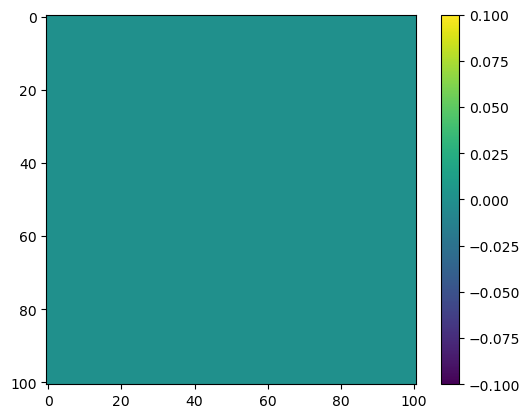

In [21]:
u0 = torch.zeros((1,1,101,101), device=device)
plt.imshow(u0[0,0].cpu().detach().numpy())
plt.colorbar()

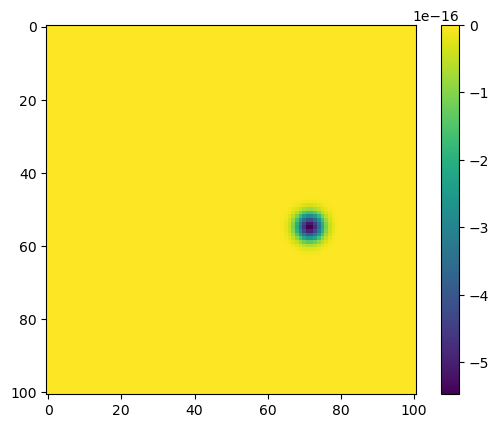

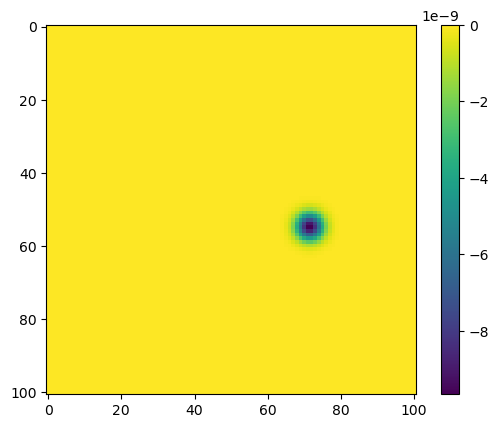

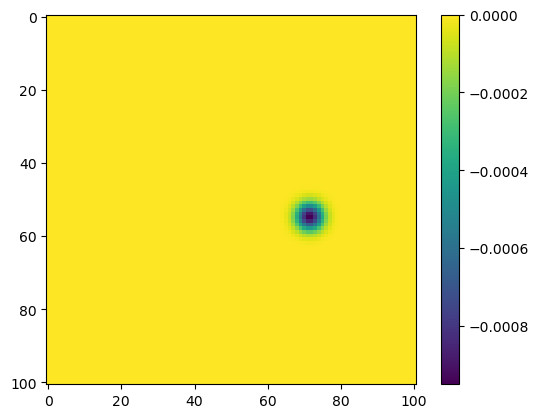

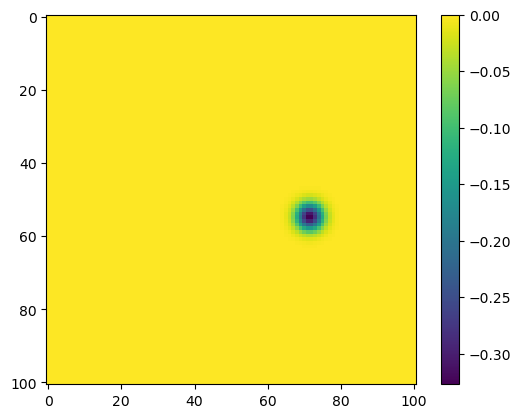

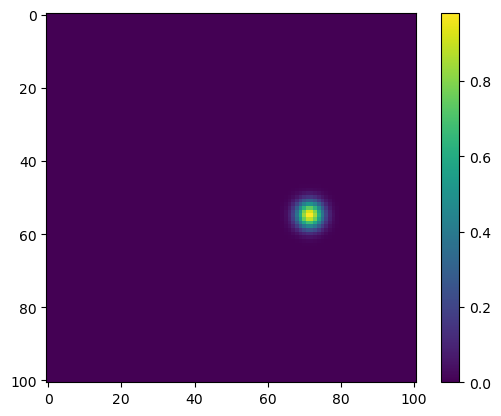

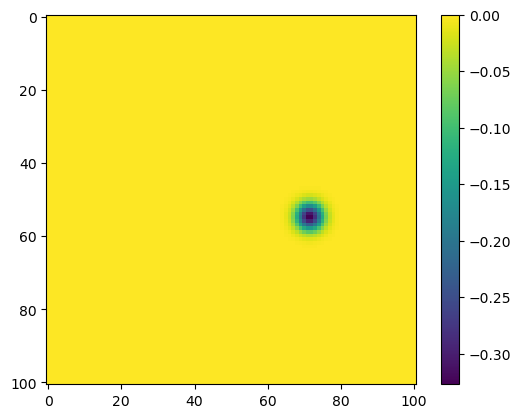

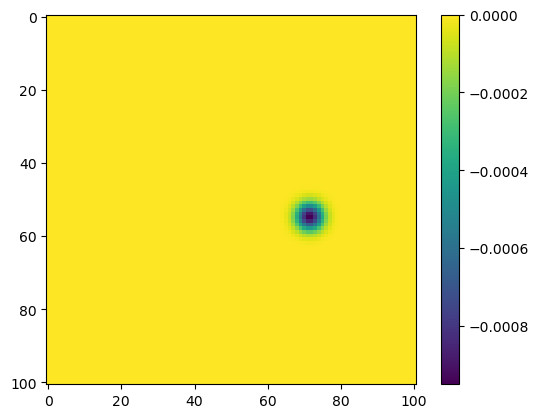

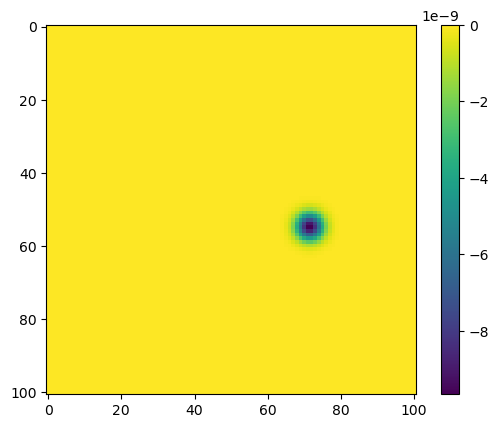

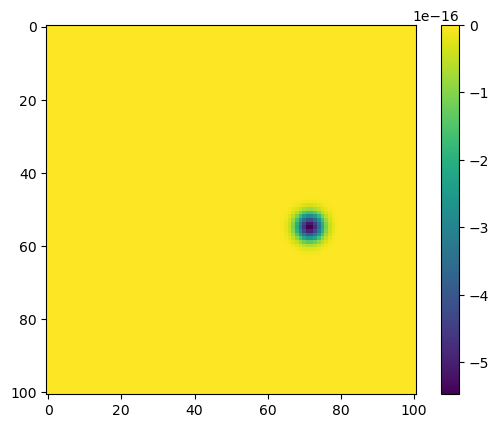

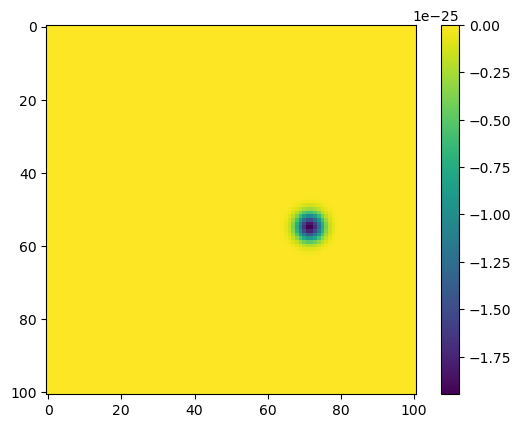

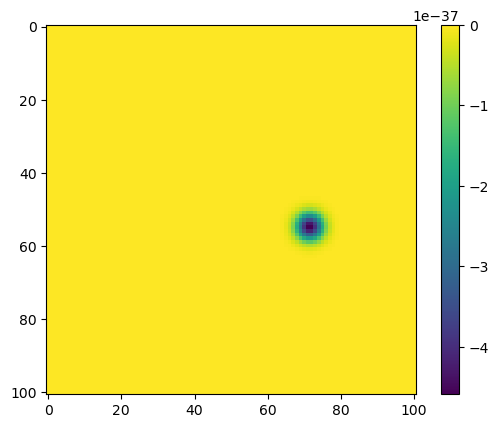

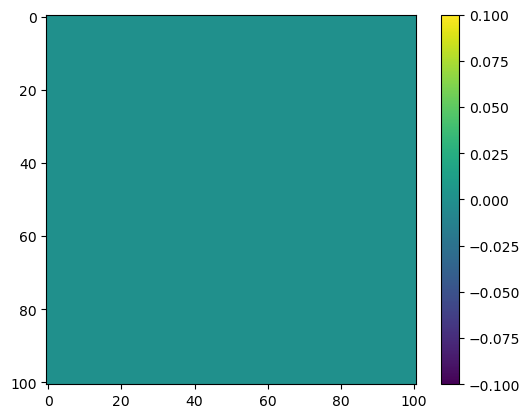

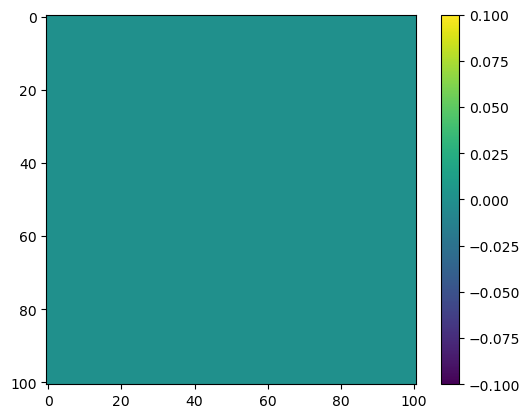

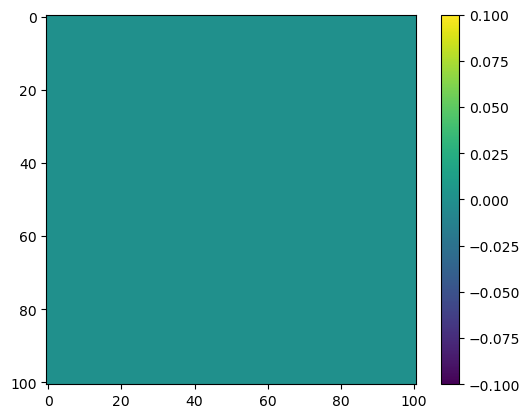

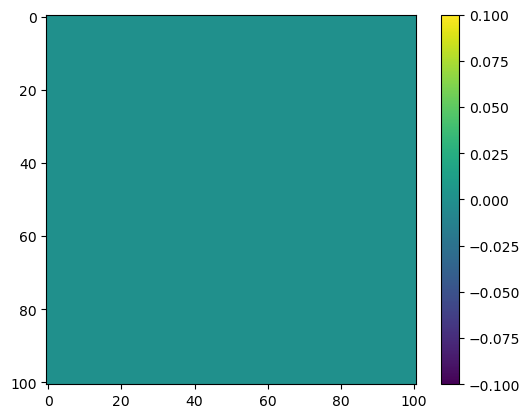

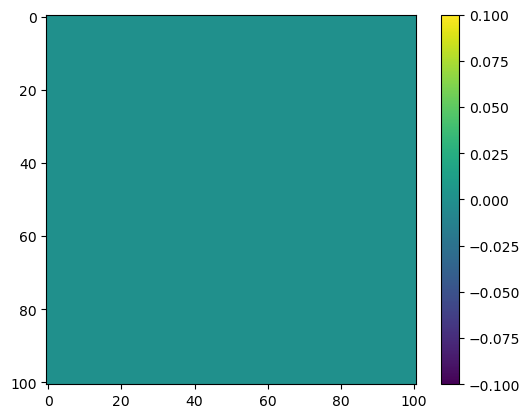

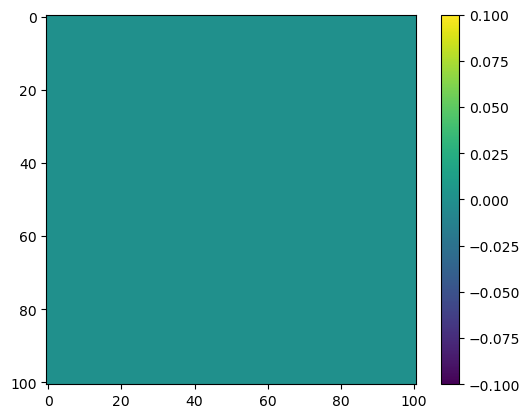

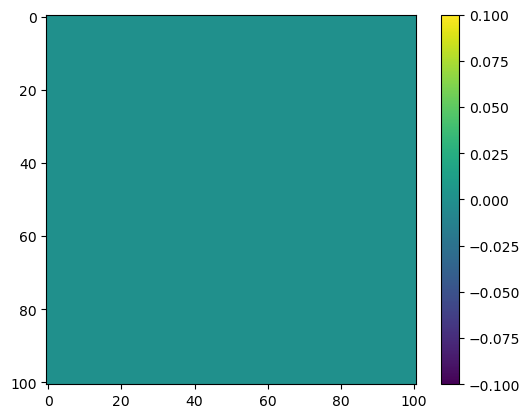

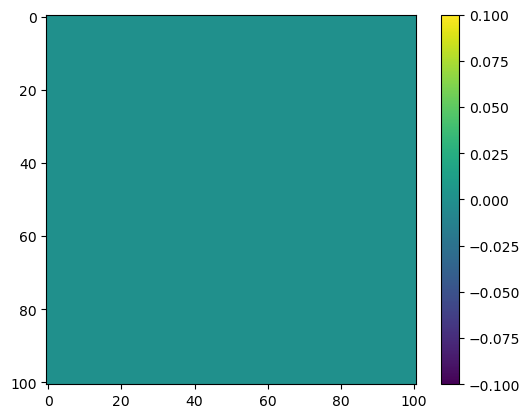

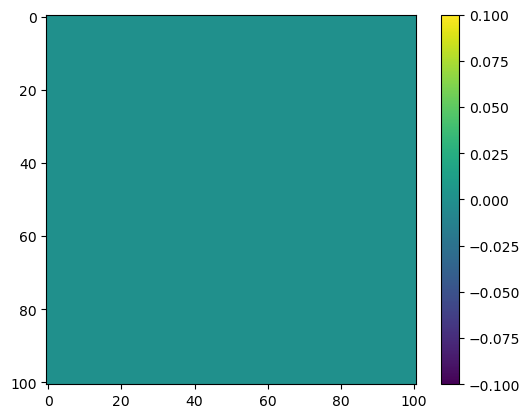

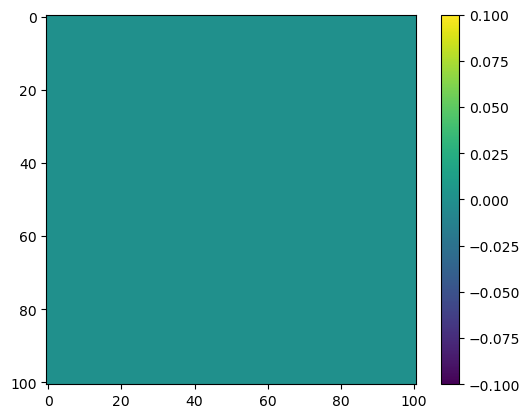

In [30]:
for t in range(0, Nt, 10):
    plt.imshow(f[t].squeeze().cpu().detach().numpy())
    plt.colorbar()
    plt.show()

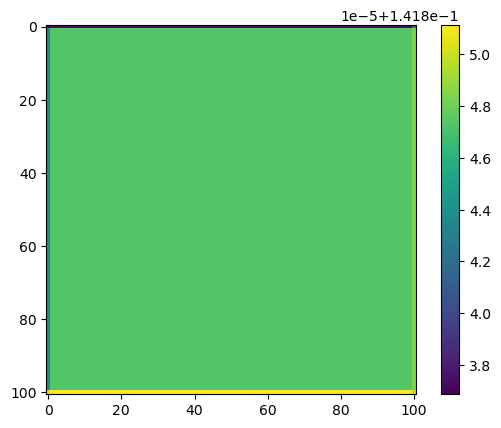

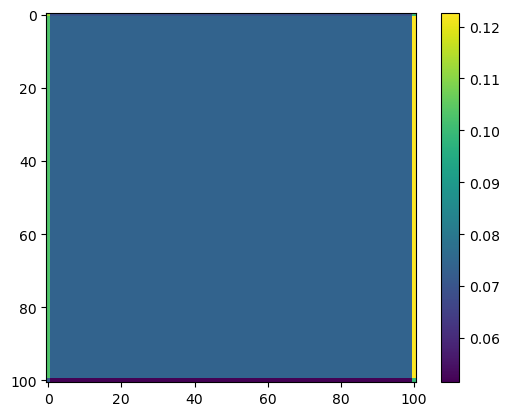

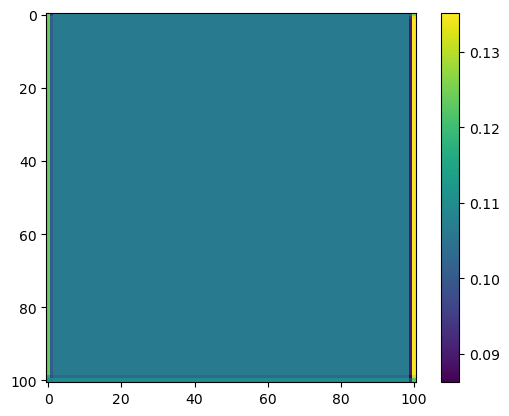

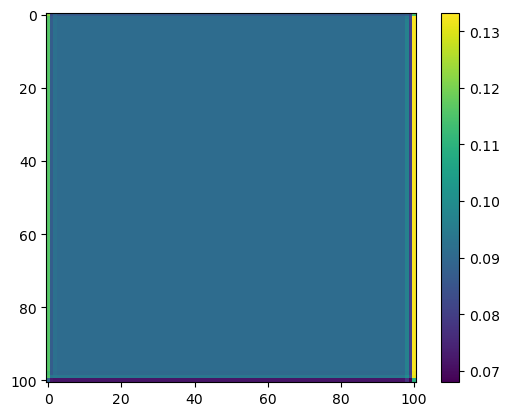

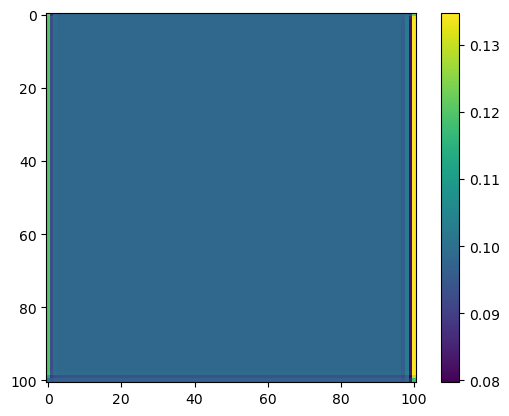

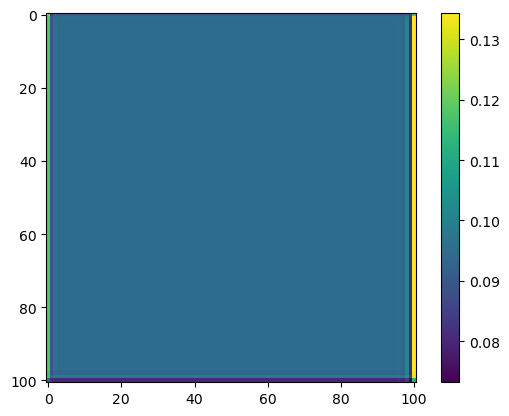

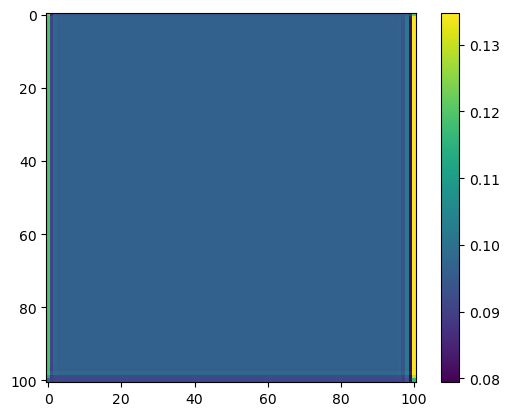

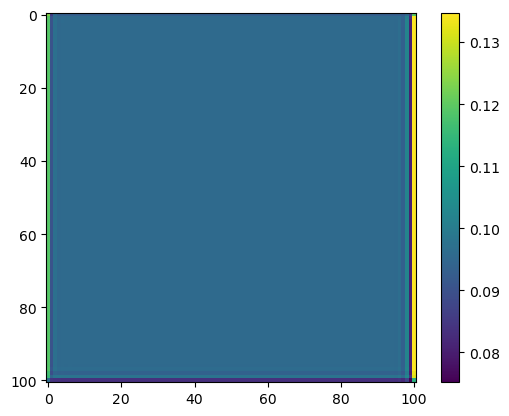

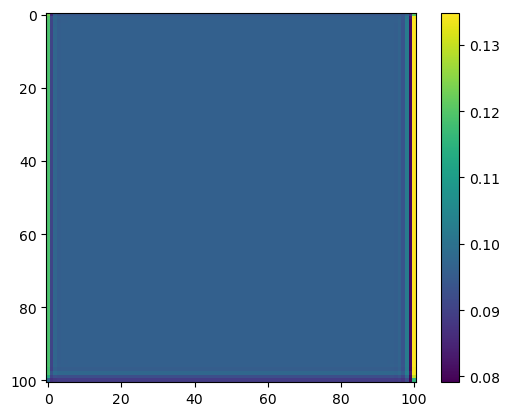

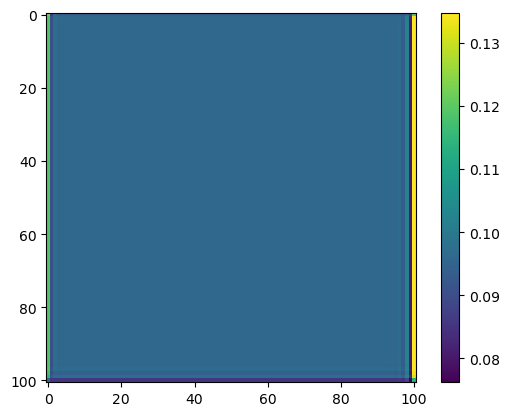

In [22]:
for t in range(10):
    ut = model(u0,c) + f[t]
    plt.imshow(ut[0,0].cpu().detach().numpy())
    plt.colorbar()
    plt.show()
    u0=ut

## Comparisons : 

Here, the different models, configurations and scenarios are tested and compared to each other.

### Scenario 1 : all information are known except $(e_x, e_y)$

Preparation for the scenario : sensors placement, epicenter and DP 

In [30]:
sensors = torch.tensor([[-0.9, -0.2],
                        [ 0.6,  0.8]], 
                        dtype=torch.float32, device=device)

e_true = (0.25, -0.10)

dp_forward_solver = DPForwardSolver(sensors=sensors,
    c=1, x_min=-1, x_max=1, y_min=-1, y_max=1,
    Nx=101, Ny=101, Nt=401, T=2,
    A=5, t0=0.1, f0=10, gamma=50)

Nt = dp_forward_solver.Nt
T = dp_forward_solver.T

with torch.no_grad():
    traces_obs = dp_forward_solver.forward(*e_true)


#### Forward solvers :

##### PINN :

In [ ]:
pinn = train_pinn(epochs=10, dt=dp_forward_solver.dt, h=dp_forward_solver.h, Nt = dp_forward_solver.Nt,
 device="cpu")

pinn_forward = PinnForwardSolver(
    model=pinn,                
    sensors=sensors,
    x_min=-1, x_max=1,
    y_min=-1, y_max=1,
    Nx=101, Ny=101,
    Nt=Nt,
    dt=dp_forward_solver.dt,
    h=dp_forward_solver.h,
    device=device,
)

##### NN : 

In [ ]:
# Dataset for surrogate forward solver to learn u(x,y,t) from simulations :
X, y = make_dataset(dp_forward_solver, n_epicenters=256, n_points_per_epi=1024)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, random_state=42)


neural_network = Neural_Network(width=256, depth=5).to(device)

# normalize
X_mean = Xtr.mean(axis=0)
X_std  = Xtr.std(axis=0) + 1e-12
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-12

Xtr_n = (Xtr - X_mean) / X_std
Xte_n = (Xte - X_mean) / X_std
ytr_n = (ytr - y_mean) / y_std
yte_n = (yte - y_mean) / y_std

# train supervised on the dataset generated from DP traces
neural_network = train_nn(neural_network, Xtr_n, ytr_n, epochs=200, batch_size=4096, lr=1e-3)

forward_nn = NNForwardSolver(neural_network, sensors, Nt, dp_forward_solver.T, device, X_mean, X_std, y_mean, y_std)


ep 000  mse=3.810e-01
ep 010  mse=6.247e-02
ep 020  mse=3.269e-02
ep 030  mse=1.415e-02
ep 040  mse=8.218e-03
ep 050  mse=5.143e-03
ep 060  mse=3.310e-03
ep 070  mse=2.649e-03
ep 080  mse=2.135e-03
ep 090  mse=1.578e-03
ep 100  mse=1.237e-03
ep 110  mse=1.276e-03
ep 120  mse=1.159e-03
ep 130  mse=1.006e-03
ep 140  mse=9.846e-04
ep 150  mse=8.558e-04
ep 160  mse=8.991e-04
ep 170  mse=9.688e-04
ep 180  mse=8.170e-04
ep 190  mse=7.796e-04


#### Inverse function :

Given the observed seismograms $\mathcal S_{\text{obs}}$, it estimates the epicenter $(e_x,e_y)$ by minimizing the difference between observed and the predicted seismograms using gradient-based optimization.

$(e_x^*, e_y^*) \;=\; \arg\min_{(e_x,e_y)} \; \left\| \mathcal S_\theta(e_x,e_y) - \mathcal S_{\text{obs}} \right\|^2$

We will now test with different forward operators.

##### DP :

In [31]:
e_hat_dp, traces_dp, _ = inverse_function(
    forward=dp_forward_solver,
    traces_obs=traces_obs,
    dt=dp_forward_solver.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=1,
    lam=1e-6,
)

100%|██████████| 50/50 [00:13<00:00,  3.68it/s]


##### PINN :

In [ ]:
model_pinn, cfg = load_pinn("pinn_physics_only2.pt", device=device) # uncomment when loading a saved model

forward_pinn = PINNForwardSolver2D(
    model=model_pinn,
    sensors=sensors,
    Nt=Nt,
    T=cfg.T,
    x_min=cfg.x_min, x_max=cfg.x_max,
    y_min=cfg.y_min, y_max=cfg.y_max,
    device=device,
)

e_hat_pinn_t0, traces_pinn_t0, n_star = inverse_function(
    forward=forward_pinn,
    traces_obs=traces_obs,
    dt=forward_pinn.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=0.2,
    lam=1e-3,
)

e_hat_pinn_t03, traces_pinn_t03, n_star = inverse_function(
    forward=forward_pinn,
    traces_obs=traces_obs,
    dt=forward_pinn.dt,
    t_star=0.8,
    init=(0.0, 0.0),
    steps=50,
    lr=0.2,
    lam=1e-3,
)

100%|██████████| 50/50 [00:16<00:00,  3.08it/s]


##### NN :

In [ ]:
e_hat_nn, traces_nn, n_star = inverse_function(
    forward=forward_nn,
    traces_obs=traces_obs,   
    dt=forward_nn.dt,
    t_star=0.0,
    init=(0.0, 0.0),
    steps=50,
    lr=0.2,
    lam=1e-6,
)

100%|██████████| 50/50 [00:21<00:00,  2.28it/s]


##### ML :
Test using a ML model to directly predict the epicenter (no inverse function).

In [33]:
# Datset for direct inversion, to learn (e_x,e_y) from seismograms
Xinv, yinv = make_inverse_dataset(dp_forward_solver, n_epicenters=256)
Xtr_inv, Xte_inv, ytr_inv, yte_inv = train_test_split(Xinv, yinv, test_size=0.15, random_state=42)


model_ml = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model_ml = MultiOutputRegressor(model_ml, n_jobs=-1)
model_ml.fit(Xtr_inv, ytr_inv)
pred_ml = model_ml.predict(Xte_inv)
e_hat_ml = model_ml.predict(traces_obs.reshape(1, -1))[0]

256it [00:15, 16.97it/s]


#### Results :
Shows the seismograms obtained by all forward operators and their predicted location of the epicenter.

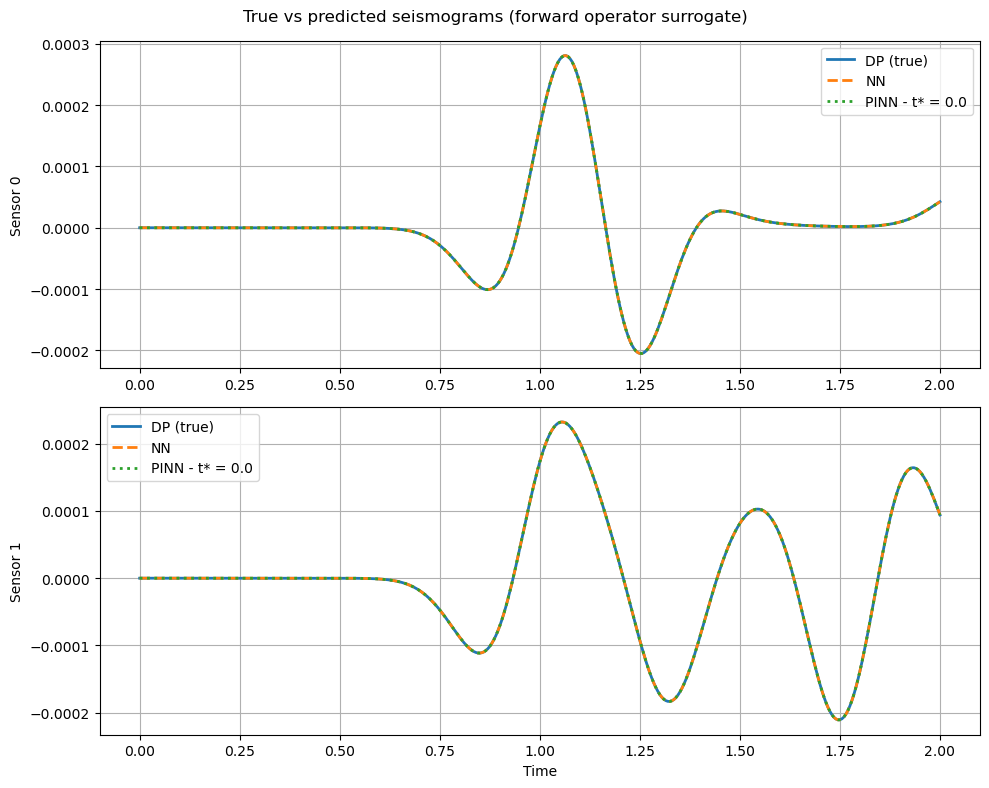

Using different forward solver as surrogate :
True epicenter : (0.25, -0.1)
DP : (tensor(0.2500), tensor(-0.1000))
RF :  (0.2667051650013136, -0.16374903544494587)


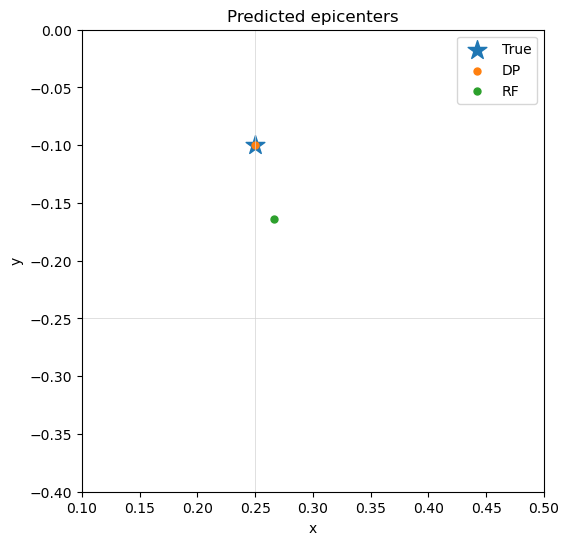

In [34]:
# plot_seimograms(traces_obs, traces_ml, traces_nn, traces_pinn_t03, dp_forward_solver)
plot_seimograms(traces_obs,traces_dp, traces_dp, traces_dp, T, Nt)

print('Using different forward solver as surrogate :')
print("True epicenter :", e_true)
print("DP :", (e_hat_dp[0], e_hat_dp[1]))
# print("PINN (t* = 0.0) :", (e_hat_pinn_t0[0], e_hat_pinn_t0[1]))
# print("PINN (t* = 0.3) :", (e_hat_pinn_t03[0], e_hat_pinn_t03[1]))
# print("NN : ",(e_hat_nn[0], e_hat_nn[1]))
print("RF : ",(e_hat_ml[0], e_hat_ml[1]))
plot_epicenters(
    e_true=e_true,
    e_hat_dp=(e_hat_dp[0], e_hat_dp[1]),
    # e_hat_pinn=(e_hat_pinn_t0[0], e_hat_pinn_t0[1]),
    # e_hat_nn=(e_hat_nn[0], e_hat_nn[1]),
    e_hat_ml=(e_hat_ml[0], e_hat_ml[1]),
    # e_hat_pinn_t03=(e_hat_pinn_t03[0], e_hat_pinn_t03[1])
)

In [23]:
grid_x = torch.linspace(-1,1,10)
grid_y = torch.linspace(-1,1,10)

loss_map = torch.zeros(10,10)

for i,x in enumerate(grid_x):
    for j,y in enumerate(grid_y):
        pred = dp_forward_solver.forward(x,y)
        loss_map[j,i] = ((pred - traces_obs)**2).sum()

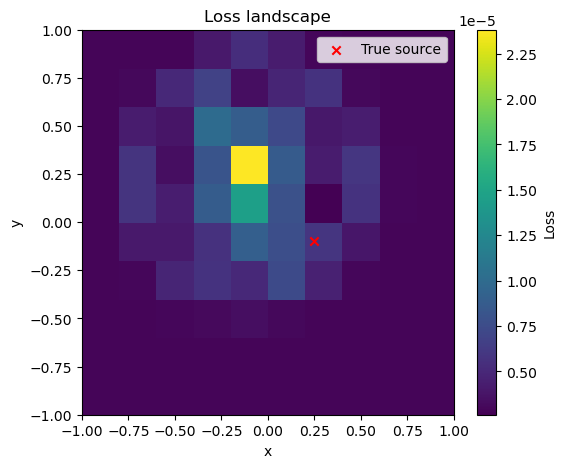

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(
    loss_map.cpu().numpy(),
    extent=[-1, 1, -1, 1],   # bornes du domaine
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Loss")
plt.scatter(e_true[0], e_true[1], c="red", marker="x", label="True source")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Loss landscape")
plt.show()

In [25]:
with torch.no_grad():
    pred_true = dp_forward_solver.forward(*e_true)
    pred_shift = dp_forward_solver.forward(e_true[0]+1e-4, e_true[1])

print(((pred_true - pred_shift)**2).sum())

tensor(1.0262e-11)


### Scenario 2 : Unknown C